In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

df.columns = [c.strip() for c in df.columns]
if "Timestamp" in df.columns:
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
df = df.sort_values("Timestamp").drop_duplicates(subset=["Timestamp"]).reset_index(drop=True)

df.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments,Month,Hour
0,2021-08-09 00:01:00,474.2,345.7,213.3,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN,8,0
1,2021-08-09 00:02:00,474.2,345.7,213.3,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN,8,0
2,2021-08-09 00:03:00,474.2,345.7,213.3,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN,8,0
3,2021-08-09 00:04:00,474.2,345.7,213.3,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN,8,0
4,2021-08-09 00:05:00,474.2,345.7,213.3,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN,8,0


## data cleaning

In [3]:
data_path = '../data/benin-malanville.csv'
df = pd.read_csv(data_path)


In [20]:
display(df.describe(include="all"))
nulls = df.isna().mean().sort_values(ascending=False)
display(nulls)
over5 = nulls[nulls > 0.05]
print("Columns with >5% nulls:", list(over5.index))


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments,Month,Hour
count,525600,525600.00000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0,525600.000000,525600.000000
mean,2022-02-07 12:00:30.000000512,474.91019,348.869739,215.870093,236.524528,228.737160,28.179683,54.487969,2.071892,2.743631,0.473390,153.435172,8.582407,994.197199,0.000923,0.001905,35.246026,32.471736,NaN,6.526027,11.500000
min,2021-08-09 00:01:00,0.00000,0.000000,0.000000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000,NaN,1.000000,0.000000
25%,2021-11-08 06:00:45,464.70000,345.700000,210.700000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000,NaN,4.000000,5.750000
50%,2022-02-07 12:00:30,474.20000,345.700000,213.300000,4.500000,4.300000,28.000000,55.100000,1.900000,2.400000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000,NaN,7.000000,11.500000
75%,2022-05-09 18:00:15,481.50000,345.700000,213.300000,463.600000,447.600000,32.300000,80.100000,3.000000,3.900000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000,NaN,10.000000,17.250000
max,2022-08-09 00:00:00,1160.00000,929.100000,543.700000,1215.000000,1177.000000,43.800000,100.000000,6.600000,8.400000,4.200000,360.000000,99.400000,1003.000000,1.000000,2.500000,81.000000,72.500000,NaN,12.000000,23.000000
std,NaN,227.44441,193.297378,96.009175,326.815176,316.357415,5.924297,28.073069,1.506107,1.898486,0.273395,102.332842,6.385864,2.474993,0.030363,0.037115,14.807258,12.348743,NaN,3.447855,6.922193


Comments         1.0
GHI              0.0
DNI              0.0
DHI              0.0
Timestamp        0.0
ModA             0.0
ModB             0.0
RH               0.0
Tamb             0.0
WSgust           0.0
WSstdev          0.0
WD               0.0
WS               0.0
WDstdev          0.0
BP               0.0
Precipitation    0.0
Cleaning         0.0
TModA            0.0
TModB            0.0
Month            0.0
Hour             0.0
dtype: float64

Columns with >5% nulls: ['Comments']


## Solar plausibilty rules

In [ ]:

dfc = df.copy()

# Irradiance can't be negative
for c in ["GHI","DNI","DHI","ModA","ModB"]:
    if c in dfc: dfc.loc[dfc[c] < 0, c] = np.nan

# Physical relationship: DHI <= GHI when both exist
if {"DHI","GHI"}.issubset(dfc.columns):
    dfc.loc[dfc["DHI"] > dfc["GHI"], "DHI"] = np.nan

# RH in [0,100]
if "RH" in dfc: dfc.loc[(dfc["RH"] < 0) | (dfc["RH"] > 100), "RH"] = np.nan

# Wind speeds >= 0
for c in ["WS","WSgust","WSstdev"]:
    if c in dfc: dfc.loc[dfc[c] < 0, c] = np.nan

# Wind direction in [0,360]
if "WD" in dfc: dfc.loc[(dfc["WD"] < 0) | (dfc["WD"] > 360), "WD"] = np.nan
if "WDstdev" in dfc: dfc.loc[dfc["WDstdev"] < 0, "WDstdev"] = np.nan

# BP (pressure) plausible sea-level range
if "BP" in dfc: dfc.loc[(dfc["BP"] < 800) | (dfc["BP"] > 1100), "BP"] = np.nan

# Precip >= 0
if "Precipitation" in dfc: dfc.loc[dfc["Precipitation"] < 0, "Precipitation"] = np.nan

# Temperatures in a broad real-world range
for c in ["Tamb","TModA","TModB"]:
    if c in dfc: dfc.loc[(dfc[c] < -50) | (dfc[c] > 80), c] = np.nan

df_after_rules = dfc.copy()
df_after_rules.describe().T.head(10)


,count,mean,min,25%,50%,75%,max,std
Timestamp,525600,2022-02-07 12:00:30.000000512,2021-08-09 00:01:00,2021-11-08 06:00:45,2022-02-07 12:00:30,2022-05-09 18:00:15,2022-08-09 00:00:00,NaN
GHI,525600.0,474.91019,0.0,464.7,474.2,481.5,1160.0,227.44441
DNI,525600.0,348.869739,0.0,345.7,345.7,345.7,929.1,193.297378
DHI,519758.0,217.515468,0.0,213.3,213.3,213.3,543.7,94.674362
ModA,525600.0,236.524528,0.0,0.0,4.5,463.6,1215.0,326.815176
ModB,525600.0,228.73716,0.0,0.0,4.3,447.6,1177.0,316.357415
Tamb,525600.0,28.179683,11.0,24.2,28.0,32.3,43.8,5.924297
RH,525600.0,54.487969,2.1,28.8,55.1,80.1,100.0,28.073069
WS,525600.0,2.071892,0.0,1.0,1.9,3.0,6.6,1.506107
WSgust,525600.0,2.743631,0.0,1.3,2.4,3.9,8.4,1.898486


##Z- Score outlier

In [24]:
z_cols = [c for c in ["GHI","DNI","DHI","ModA","ModB","WS","WSgust"] if c in dfc.columns]
for c in z_cols:
    s = pd.to_numeric(dfc[c], errors="coerce")
    mask = s.notna()
    if mask.sum() > 0:
        z = stats.zscore(s[mask], nan_policy="omit")
        out_mask = pd.Series(False, index=dfc.index)
        out_mask[mask.index[mask]] = np.abs(z) > 3
        dfc.loc[out_mask, c] = np.nan

df_after_outliers = dfc.copy()
dfc[z_cols].describe()


,GHI,DNI,DHI,ModA,ModB,WS,WSgust
count,525580.000000,525597.000000,512755.000000,525600.000000,525600.000000,525111.000000,525600.000000
mean,474.884154,348.866428,213.362588,236.524528,228.737160,2.067675,2.743631
std,227.409573,193.292960,88.338005,326.815176,316.357415,1.500453,1.898486
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,464.600000,345.700000,213.100000,0.000000,0.000000,1.000000,1.300000
50%,474.200000,345.700000,213.300000,4.500000,4.300000,1.900000,2.400000
75%,481.400000,345.700000,213.300000,463.600000,447.600000,3.000000,3.900000
max,1157.000000,928.600000,501.500000,1215.000000,1177.000000,6.500000,8.400000


## Medain Imputation

In [25]:
num_cols = dfc.select_dtypes(include=[np.number]).columns
for c in num_cols:
    med = dfc[c].median()
    dfc[c] = dfc[c].fillna(med)

df_clean = dfc.copy()
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 21 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Timestamp      525600 non-null  datetime64[ns]
 1   GHI            525600 non-null  float64       
 2   DNI            525600 non-null  float64       
 3   DHI            525600 non-null  float64       
 4   ModA           525600 non-null  float64       
 5   ModB           525600 non-null  float64       
 6   Tamb           525600 non-null  float64       
 7   RH             525600 non-null  float64       
 8   WS             525600 non-null  float64       
 9   WSgust         525600 non-null  float64       
 10  WSstdev        525600 non-null  float64       
 11  WD             525600 non-null  float64       
 12  WDstdev        525600 non-null  float64       
 13  BP             525600 non-null  float64       
 14  Cleaning       525600 non-null  int64         
 15  

c:\Users\user\Downloads\Solar-challenge-week0\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


## quick profiling and missingness check point

In [26]:
display(df.describe(include="all").T.round(3))                     # raw
display(df_after_rules[z_cols].describe().T.round(3))              # after solar rules
display(df_after_outliers[z_cols].describe().T.round(3))           # after outliers
display(df_clean.describe(include="all").T.round(3))               # final
missing = df_clean.isna().mean().sort_values(ascending=False)
missing.head(12)


,count,mean,min,25%,50%,75%,max,std
Timestamp,525600,2022-02-07 12:00:30.000000512,2021-08-09 00:01:00,2021-11-08 06:00:45,2022-02-07 12:00:30,2022-05-09 18:00:15,2022-08-09 00:00:00,NaN
GHI,525600.0,474.91019,0.0,464.7,474.2,481.5,1160.0,227.44441
DNI,525600.0,348.869739,0.0,345.7,345.7,345.7,929.1,193.297378
DHI,525600.0,215.870093,0.0,210.7,213.3,213.3,543.7,96.009175
ModA,525600.0,236.524528,0.0,0.0,4.5,463.6,1215.0,326.815176
ModB,525600.0,228.73716,0.0,0.0,4.3,447.6,1177.0,316.357415
Tamb,525600.0,28.179683,11.0,24.2,28.0,32.3,43.8,5.924297
RH,525600.0,54.487969,2.1,28.8,55.1,80.1,100.0,28.073069
WS,525600.0,2.071892,0.0,1.0,1.9,3.0,6.6,1.506107
WSgust,525600.0,2.743631,0.0,1.3,2.4,3.9,8.4,1.898486


,count,mean,std,min,25%,50%,75%,max
GHI,525600.0,474.910,227.444,0.0,464.7,474.2,481.5,1160.0
DNI,525600.0,348.870,193.297,0.0,345.7,345.7,345.7,929.1
DHI,519758.0,217.515,94.674,0.0,213.3,213.3,213.3,543.7
ModA,525600.0,236.525,326.815,0.0,0.0,4.5,463.6,1215.0
ModB,525600.0,228.737,316.357,0.0,0.0,4.3,447.6,1177.0
WS,525600.0,2.072,1.506,0.0,1.0,1.9,3.0,6.6
WSgust,525600.0,2.744,1.898,0.0,1.3,2.4,3.9,8.4


,count,mean,std,min,25%,50%,75%,max
GHI,525580.0,474.884,227.410,0.0,464.6,474.2,481.4,1157.0
DNI,525597.0,348.866,193.293,0.0,345.7,345.7,345.7,928.6
DHI,512755.0,213.363,88.338,0.0,213.1,213.3,213.3,501.5
ModA,525600.0,236.525,326.815,0.0,0.0,4.5,463.6,1215.0
ModB,525600.0,228.737,316.357,0.0,0.0,4.3,447.6,1177.0
WS,525111.0,2.068,1.500,0.0,1.0,1.9,3.0,6.5
WSgust,525600.0,2.744,1.898,0.0,1.3,2.4,3.9,8.4


,count,mean,min,25%,50%,75%,max,std
Timestamp,525600,2022-02-07 12:00:30.000000512,2021-08-09 00:01:00,2021-11-08 06:00:45,2022-02-07 12:00:30,2022-05-09 18:00:15,2022-08-09 00:00:00,NaN
GHI,525600.0,474.884128,0.0,464.7,474.2,481.4,1157.0,227.405246
DNI,525600.0,348.866409,0.0,345.7,345.7,345.7,928.6,193.292409
DHI,525600.0,213.361059,0.0,213.3,213.3,213.3,501.5,87.251892
ModA,525600.0,236.524528,0.0,0.0,4.5,463.6,1215.0,326.815176
ModB,525600.0,228.73716,0.0,0.0,4.3,447.6,1177.0,316.357415
Tamb,525600.0,28.179683,11.0,24.2,28.0,32.3,43.8,5.924297
RH,525600.0,54.487969,2.1,28.8,55.1,80.1,100.0,28.073069
WS,525600.0,2.067519,0.0,1.0,1.9,3.0,6.5,1.499763
WSgust,525600.0,2.743631,0.0,1.3,2.4,3.9,8.4,1.898486


Comments     1.0
GHI          0.0
DNI          0.0
DHI          0.0
Timestamp    0.0
ModA         0.0
ModB         0.0
RH           0.0
Tamb         0.0
WSgust       0.0
WSstdev      0.0
WD           0.0
dtype: float64

## Time - series

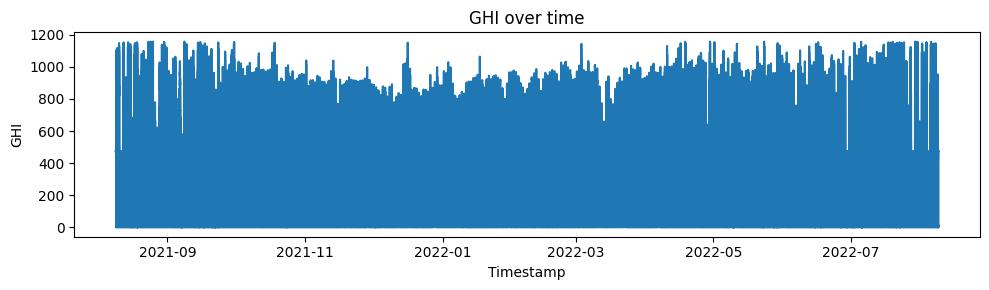

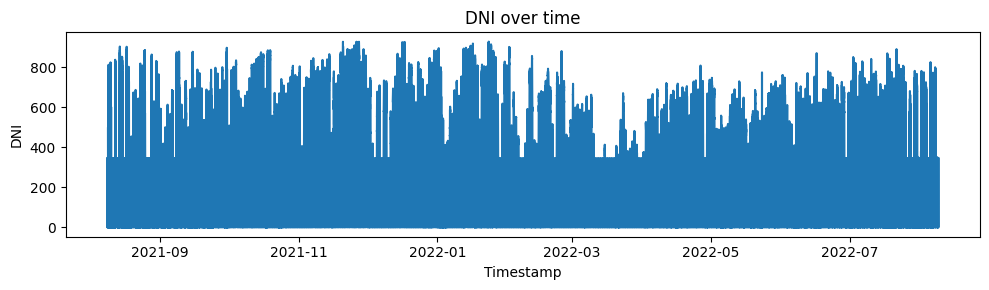

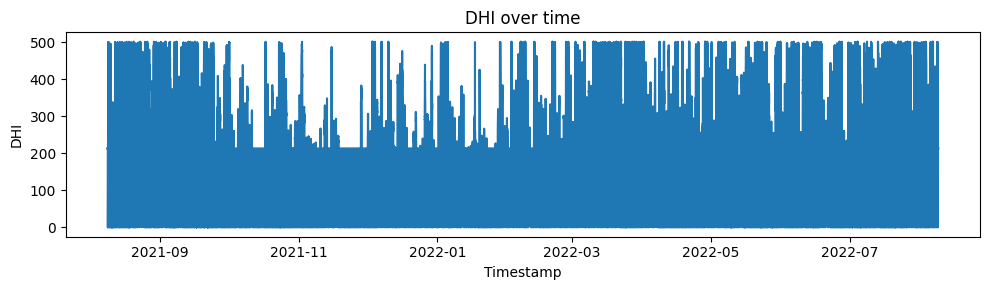

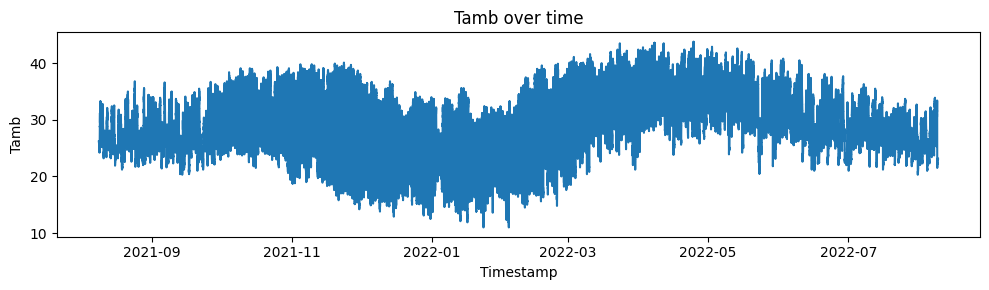

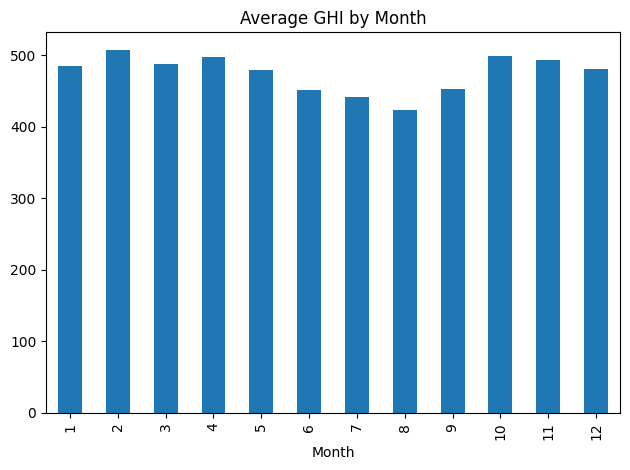

In [27]:
if "Timestamp" in df_clean:
    df_clean["Month"] = df_clean["Timestamp"].dt.month
    df_clean["Hour"]  = df_clean["Timestamp"].dt.hour

    for col in ["GHI","DNI","DHI","Tamb"]:
        if col in df_clean.columns:
            plt.figure(figsize=(10,3))
            plt.plot(df_clean["Timestamp"], df_clean[col])
            plt.title(f"{col} over time")
            plt.xlabel("Timestamp"); plt.ylabel(col)
            plt.tight_layout(); plt.show()

    if "GHI" in df_clean.columns:
        plt.figure()
        df_clean.groupby("Month")["GHI"].mean().plot(kind="bar", title="Average GHI by Month")
        plt.tight_layout(); plt.show()


cleaning and impact

,ModA,ModB
Cleaning,,
0,236.459225,228.669520
1,307.229278,301.972165


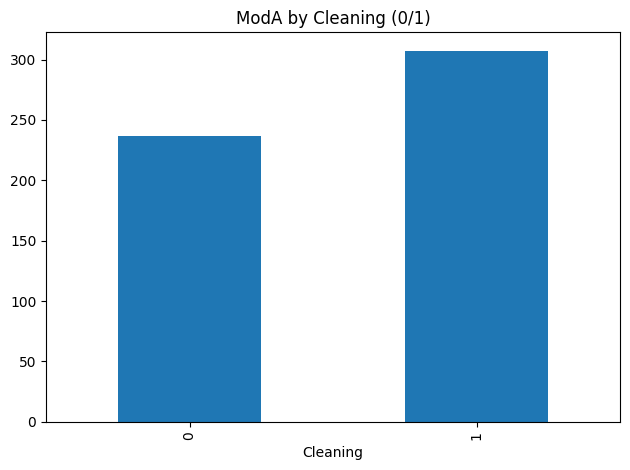

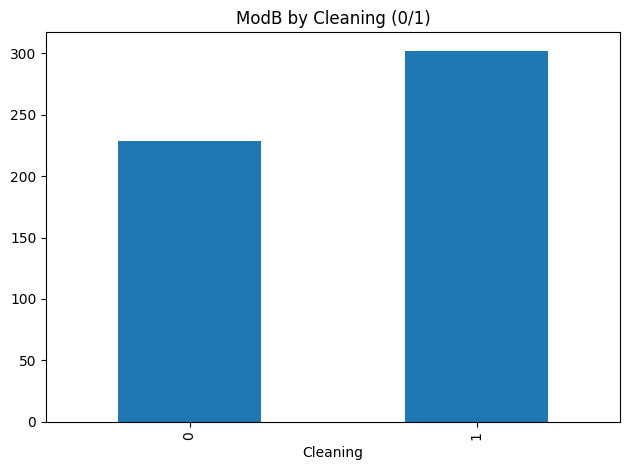

In [28]:
if "Cleaning" in df_clean.columns and {"ModA","ModB"}.issubset(df_clean.columns):
    avg = df_clean.groupby("Cleaning")[["ModA","ModB"]].mean()
    display(avg)
    for col in ["ModA","ModB"]:
        plt.figure()
        avg[col].plot(kind="bar", title=f"{col} by Cleaning (0/1)")
        plt.tight_layout(); plt.show()


## correlation

,GHI,DNI,DHI,TModA,TModB,Tamb,RH,WS,WSgust
GHI,1.000,0.697,0.634,0.566,0.524,0.290,-0.243,0.271,0.289
DNI,0.697,1.000,0.118,0.386,0.365,0.201,-0.248,0.185,0.197
DHI,0.634,0.118,1.000,0.397,0.370,0.204,-0.108,0.215,0.228
TModA,0.566,0.386,0.397,1.000,0.983,0.762,-0.344,0.463,0.496
TModB,0.524,0.365,0.370,0.983,1.000,0.823,-0.320,0.435,0.468
Tamb,0.290,0.201,0.204,0.762,0.823,1.000,-0.415,0.378,0.396
RH,-0.243,-0.248,-0.108,-0.344,-0.320,-0.415,1.000,-0.268,-0.262
WS,0.271,0.185,0.215,0.463,0.435,0.378,-0.268,1.000,0.968
WSgust,0.289,0.197,0.228,0.496,0.468,0.396,-0.262,0.968,1.000


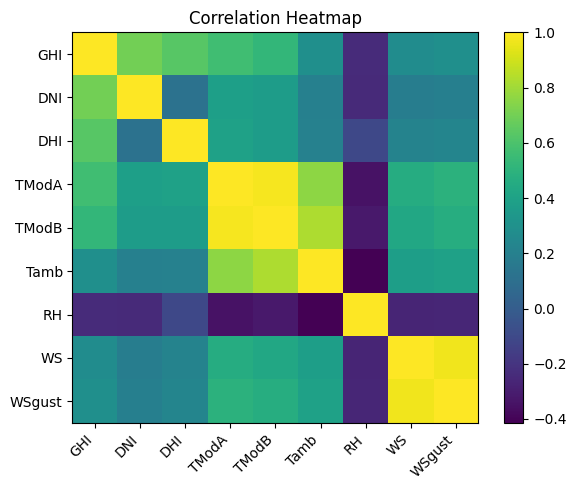

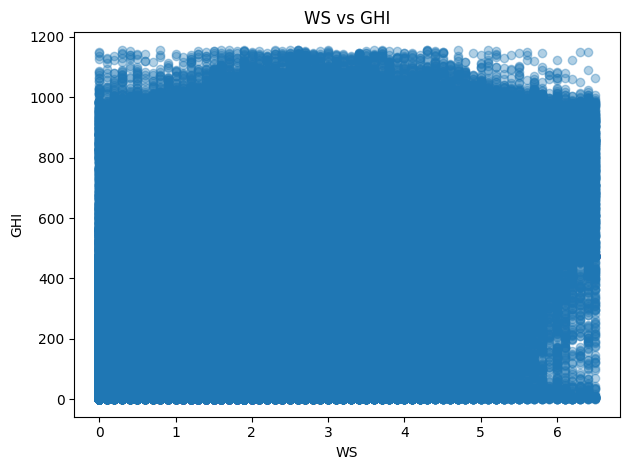

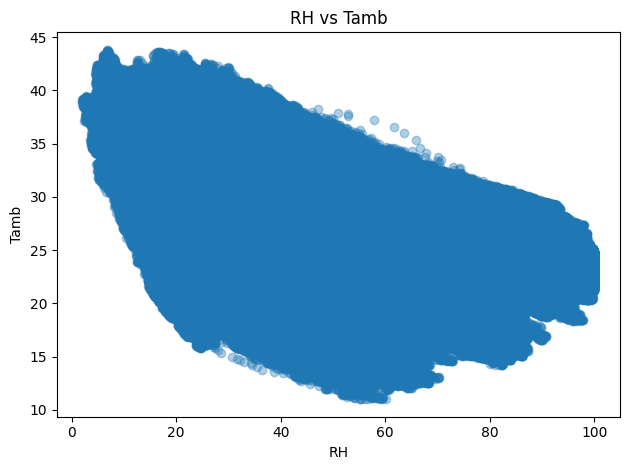

In [29]:
corr_cols = [c for c in ["GHI","DNI","DHI","TModA","TModB","Tamb","RH","WS","WSgust"] if c in df_clean.columns]
if len(corr_cols) >= 2:
    cmat = df_clean[corr_cols].corr()
    display(cmat.round(3))
    plt.figure(figsize=(6,5))
    plt.imshow(cmat, aspect="auto")
    plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
    plt.yticks(range(len(corr_cols)), corr_cols)
    plt.colorbar(); plt.title("Correlation Heatmap")
    plt.tight_layout(); plt.show()

if {"WS","GHI"}.issubset(df_clean.columns):
    plt.figure(); plt.scatter(df_clean["WS"], df_clean["GHI"], alpha=0.35)
    plt.xlabel("WS"); plt.ylabel("GHI"); plt.title("WS vs GHI")
    plt.tight_layout(); plt.show()

if {"RH","Tamb"}.issubset(df_clean.columns):
    plt.figure(); plt.scatter(df_clean["RH"], df_clean["Tamb"], alpha=0.35)
    plt.xlabel("RH"); plt.ylabel("Tamb"); plt.title("RH vs Tamb")
    plt.tight_layout(); plt.show()


## wind and distribution

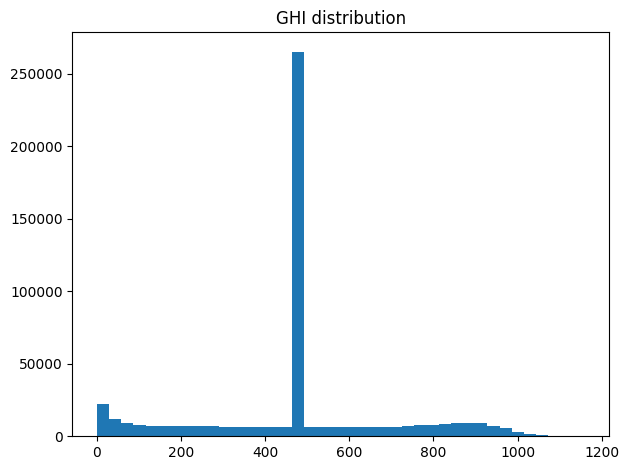

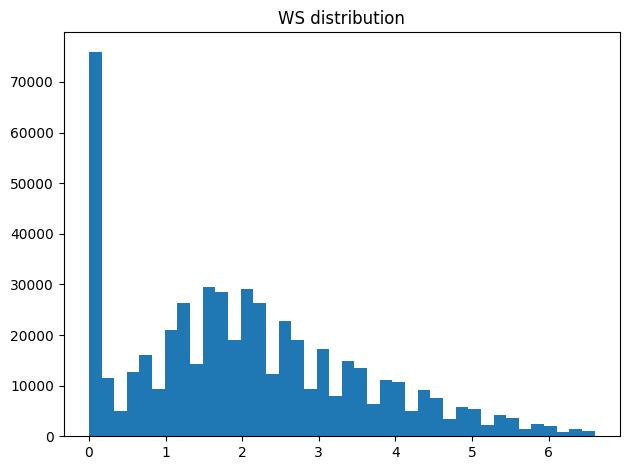

Windrose not available or data missing; skipping. Reason: No module named 'windrose'


In [15]:
# Histograms
for col in ["GHI","WS"]:
    if col in df.columns:
        plt.figure(); plt.hist(df[col].dropna(), bins=40)
        plt.title(f"{col} distribution"); plt.tight_layout(); plt.show()

# Wind rose is optional (needs 'windrose' package); skip in CI, do locally if installed
try:
    from windrose import WindroseAxes
    if {"WS","WD"}.issubset(df.columns):
        ax = WindroseAxes.from_ax()
        ax.bar(df["WD"], df["WS"], normed=True, opening=0.8)
        ax.set_title("Wind Rose (WS by WD)")
        plt.show()
except Exception as e:
    print("Windrose not available or data missing; skipping. Reason:", e)


## Temprature / RH influence

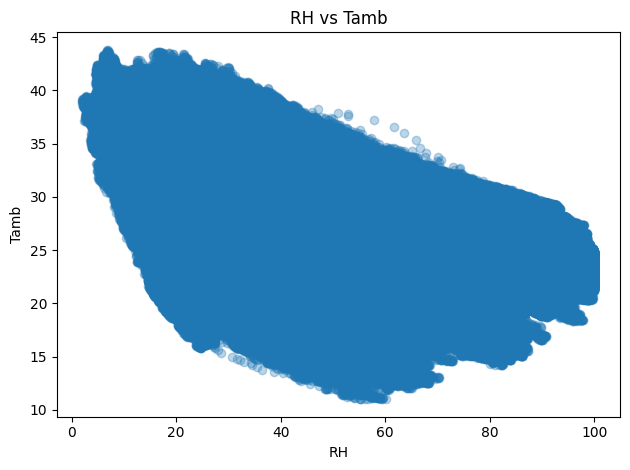

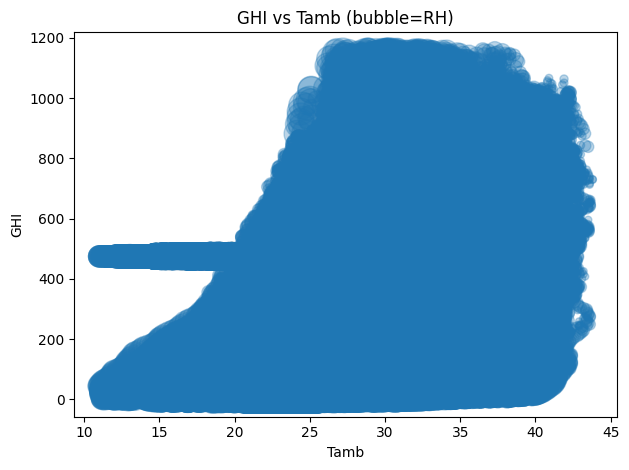

In [16]:
# Simple check of RH influence on Tamb (scatter w/ alpha)
if {"RH","Tamb"}.issubset(df.columns):
    plt.figure(); plt.scatter(df["RH"], df["Tamb"], alpha=0.3)
    plt.xlabel("RH"); plt.ylabel("Tamb"); plt.title("RH vs Tamb")
    plt.tight_layout(); plt.show()

# Bubble: GHI vs Tamb with bubble size = RH (or BP)
size_col = "RH" if "RH" in df.columns else ("BP" if "BP" in df.columns else None)
if size_col and {"GHI","Tamb"}.issubset(df.columns):
    s = df[size_col].astype(float)
    s = (s - s.min()) / (s.max() - s.min() + 1e-9) * 400 + 10
    plt.figure(); plt.scatter(df["Tamb"], df["GHI"], s=s, alpha=0.3)
    plt.xlabel("Tamb"); plt.ylabel("GHI"); plt.title(f"GHI vs Tamb (bubble={size_col})")
    plt.tight_layout(); plt.show()


##Bubble chart

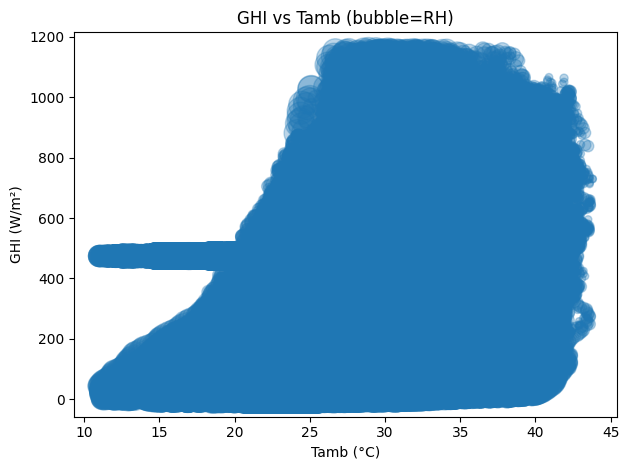

In [30]:
size_col = "RH" if "RH" in df_clean.columns else ("BP" if "BP" in df_clean.columns else None)
if size_col and {"GHI","Tamb"}.issubset(df_clean.columns):
    s = df_clean[size_col].astype(float)
    s = (s - s.min()) / (s.max() - s.min() + 1e-9) * 400 + 10
    plt.figure()
    plt.scatter(df_clean["Tamb"], df_clean["GHI"], s=s, alpha=0.3)
    plt.xlabel("Tamb (°C)"); plt.ylabel("GHI (W/m²)")
    plt.title(f"GHI vs Tamb (bubble={size_col})")
    plt.tight_layout(); plt.show()


Exporting cleaned csv

In [31]:
Path("data").mkdir(exist_ok=True)
out = Path("data") / "benin_clean.csv"
df_clean.to_csv(out, index=False)
print(f"[OK] saved: {out}")
if "Timestamp" in df_clean:
    print("Timestamp dtype:", df_clean["Timestamp"].dtype)
print("Rows:", len(df_clean), "Cols:", len(df_clean.columns))


[OK] saved: data\benin_clean.csv
Timestamp dtype: datetime64[ns]
Rows: 525600 Cols: 21
